[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/oalnaseri/mobilcom_course/blob/main/09_empirical_pathloss_models_interactive.ipynb)

> **Run this notebook in Google Colab** — click the badge above (no local install needed).
> The setup cell below installs dependencies and enables interactive `ipywidgets` sliders in Colab.

---

# 🗺️ Empirical Path-Loss Models — and the Cell Radius They Predict
### Interactive Teaching Notebook — DHBW Mobile Communications
---
Slide set 2 lists the models a planner actually uses when the terrain is not modelled in
detail:

* **Log-distance** path loss (the exponent $n$ from slide set 1)
* **Okumura–Hata** — 150 MHz … 1.5 GHz, used for GSM-R planning
* **COST 231–Hata** — the same idea extended to 1.5 … 2 GHz
* **Free space** (Friis) as the optimistic reference

Here you can put them side by side, feed in the **maximum permissible path loss** from a
link budget, and read off the **cell radius** — which is the number that decides how many
base stations get built.

---

In [1]:
# ============================================================
#  COLAB / ENVIRONMENT SETUP  (safe to run locally too)
# ============================================================
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # numpy + matplotlib ship with Colab; ensure ipywidgets is present
    !pip install -q ipywidgets

    # Required so ipywidgets sliders / interactive output render in Colab
    from google.colab import output
    output.enable_custom_widget_manager()

print("Environment ready.  IN_COLAB =", IN_COLAB)

Environment ready.  IN_COLAB = False


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#f5f5f5'
print("Libraries loaded.")

Libraries loaded.


## 📚 Theory Reference

Everything below is a **path loss in dB** for distance $d$ in km and frequency $f$ in MHz.

### Free space (Friis, $n=2$)
$$L_{FS}=32.44+20\log_{10}f_{MHz}+20\log_{10}d_{km}$$

### Log-distance
$$L(d)=L(d_0)+10\,n\log_{10}\!\frac{d}{d_0}$$
with $n=2$ free space, $n\approx4$ two-path beyond the breakpoint,
$n\approx2.7\ldots3.5$ urban LOS, $n\approx3\ldots5$ urban NLOS.

### Okumura–Hata (urban)
$$L_{urban}=69.55+26.16\log_{10}f-13.82\log_{10}h_b-a(h_m)
+\bigl(44.9-6.55\log_{10}h_b\bigr)\log_{10}d$$

$$a(h_m)=\bigl(1.1\log_{10}f-0.7\bigr)h_m-\bigl(1.56\log_{10}f-0.8\bigr)
\quad\text{(small / medium city)}$$

$$a(h_m)=3.2\bigl[\log_{10}(11.75\,h_m)\bigr]^2-4.97
\quad\text{(large city, } f\ge400\ \text{MHz)}$$

$$L_{suburban}=L_{urban}-2\left[\log_{10}\frac{f}{28}\right]^2-5.4
\qquad
L_{rural}=L_{urban}-4.78\bigl(\log_{10}f\bigr)^2+18.33\log_{10}f-40.94$$

**Validity:** $f = 150\ldots1500$ MHz, $d = 1\ldots20$ km,
$h_b = 30\ldots200$ m, $h_m = 1\ldots10$ m.

### COST 231–Hata
$$L=46.3+33.9\log_{10}f-13.82\log_{10}h_b-a(h_m)
+\bigl(44.9-6.55\log_{10}h_b\bigr)\log_{10}d+C_m$$

$C_m = 0$ dB for medium cities and suburbs, $3$ dB for metropolitan centres.
**Validity:** $f = 1500\ldots2000$ MHz.

### Cell radius
Every one of these is *linear in $\log_{10}d$*, so inverting is trivial:
$$L = A + B\log_{10}d \quad\Longrightarrow\quad d = 10^{(L_{max}-A)/B}$$

---

In [3]:
# ---------------------------------------------------------------
#  THE MODELS
# ---------------------------------------------------------------
def a_hm(f_MHz, h_m, city='medium'):
    """Mobile-antenna correction factor a(h_m) [dB]."""
    lf = np.log10(f_MHz)
    if city == 'large':
        if f_MHz >= 400:
            return 3.2*(np.log10(11.75*h_m))**2 - 4.97
        return 8.29*(np.log10(1.54*h_m))**2 - 1.1
    return (1.1*lf - 0.7)*h_m - (1.56*lf - 0.8)

def hata_AB(f_MHz, h_b, h_m, area='urban', city='medium'):
    """Okumura-Hata as L = A + B*log10(d_km)."""
    lf = np.log10(f_MHz)
    A  = 69.55 + 26.16*lf - 13.82*np.log10(h_b) - a_hm(f_MHz, h_m, city)
    B  = 44.9 - 6.55*np.log10(h_b)
    if area == 'suburban':
        A -= 2*(np.log10(f_MHz/28.0))**2 + 5.4
    elif area == 'rural':
        A += -4.78*lf**2 + 18.33*lf - 40.94
    return A, B

def cost231_AB(f_MHz, h_b, h_m, city='medium'):
    """COST 231-Hata as L = A + B*log10(d_km)."""
    lf = np.log10(f_MHz)
    Cm = 3.0 if city == 'large' else 0.0
    A  = 46.3 + 33.9*lf - 13.82*np.log10(h_b) - a_hm(f_MHz, h_m, city) + Cm
    B  = 44.9 - 6.55*np.log10(h_b)
    return A, B

def freespace_AB(f_MHz):
    return 32.44 + 20*np.log10(f_MHz), 20.0

def logdistance_AB(f_MHz, n, d0_km=0.1):
    """Anchored on free space at d0."""
    A0, _ = freespace_AB(f_MHz)
    L0 = A0 + 20*np.log10(d0_km)
    return L0 - 10*n*np.log10(d0_km), 10.0*n

def L_of_d(AB, d_km):
    A, B = AB
    return A + B*np.log10(d_km)

def cell_radius(AB, L_max_dB):
    """Distance at which the model reaches L_max  ->  cell radius in km."""
    A, B = AB
    return 10.0**((L_max_dB - A)/B)

VALID = {'Okumura-Hata': dict(f=(150, 1500), d=(1, 20), hb=(30, 200), hm=(1, 10)),
         'COST 231-Hata': dict(f=(1500, 2000), d=(1, 20), hb=(30, 200), hm=(1, 10))}

def check_validity(name, f, d_hi, hb, hm):
    v = VALID[name]; msgs = []
    if not v['f'][0] <= f <= v['f'][1]:  msgs.append(f"f={f:.0f} MHz outside {v['f']}")
    if not v['hb'][0] <= hb <= v['hb'][1]: msgs.append(f"h_b={hb:.0f} m outside {v['hb']}")
    if not v['hm'][0] <= hm <= v['hm'][1]: msgs.append(f"h_m={hm:.1f} m outside {v['hm']}")
    return msgs

print("Models defined.")

Models defined.


In [4]:
# ---------------------------------------------------------------
#  SANITY CHECK  —  a textbook GSM900 case
#  f = 900 MHz, h_b = 30 m, h_m = 1.5 m, d = 1 km, medium city, urban
# ---------------------------------------------------------------
A, B = hata_AB(900, 30, 1.5, 'urban', 'medium')
print(f"Okumura-Hata urban, f=900 MHz, h_b=30 m, h_m=1.5 m")
print(f"   a(h_m)      = {a_hm(900, 1.5):.3f} dB")
print(f"   L(1 km)     = {L_of_d((A, B), 1.0):.1f} dB")
print(f"   L(5 km)     = {L_of_d((A, B), 5.0):.1f} dB")
print(f"   slope B     = {B:.2f} dB/decade  ->  path loss exponent n = {B/10:.2f}")
print(f"   free space  = {L_of_d(freespace_AB(900), 1.0):.1f} dB at 1 km"
      f"   ->  Hata is {L_of_d((A,B),1.0)-L_of_d(freespace_AB(900),1.0):.0f} dB worse")

print()
As, Bs = hata_AB(900, 30, 1.5, 'suburban'); Ar, Br = hata_AB(900, 30, 1.5, 'rural')
for nm, ab in [('urban', (A, B)), ('suburban', (As, Bs)), ('rural', (Ar, Br))]:
    print(f"   {nm:<9s} L(5 km) = {L_of_d(ab, 5.0):6.1f} dB")

print("\n--- and now the number that matters ---")
L_max = 143.0     # the max. propagation loss from the GSM1800 link budget, slide set 1
for nm, ab in [('urban', (A, B)), ('suburban', (As, Bs)), ('rural', (Ar, Br))]:
    print(f"   {nm:<9s} cell radius for L_max = {L_max:.0f} dB :"
          f" {cell_radius(ab, L_max):6.2f} km")

Okumura-Hata urban, f=900 MHz, h_b=30 m, h_m=1.5 m
   a(h_m)      = 0.016 dB
   L(1 km)     = 126.4 dB
   L(5 km)     = 151.0 dB
   slope B     = 35.22 dB/decade  ->  path loss exponent n = 3.52
   free space  = 91.5 dB at 1 km   ->  Hata is 35 dB worse

   urban     L(5 km) =  151.0 dB
   suburban  L(5 km) =  141.1 dB
   rural     L(5 km) =  122.5 dB

--- and now the number that matters ---
   urban     cell radius for L_max = 143 dB :   2.96 km
   suburban  cell radius for L_max = 143 dB :   5.67 km
   rural     cell radius for L_max = 143 dB :  19.07 km


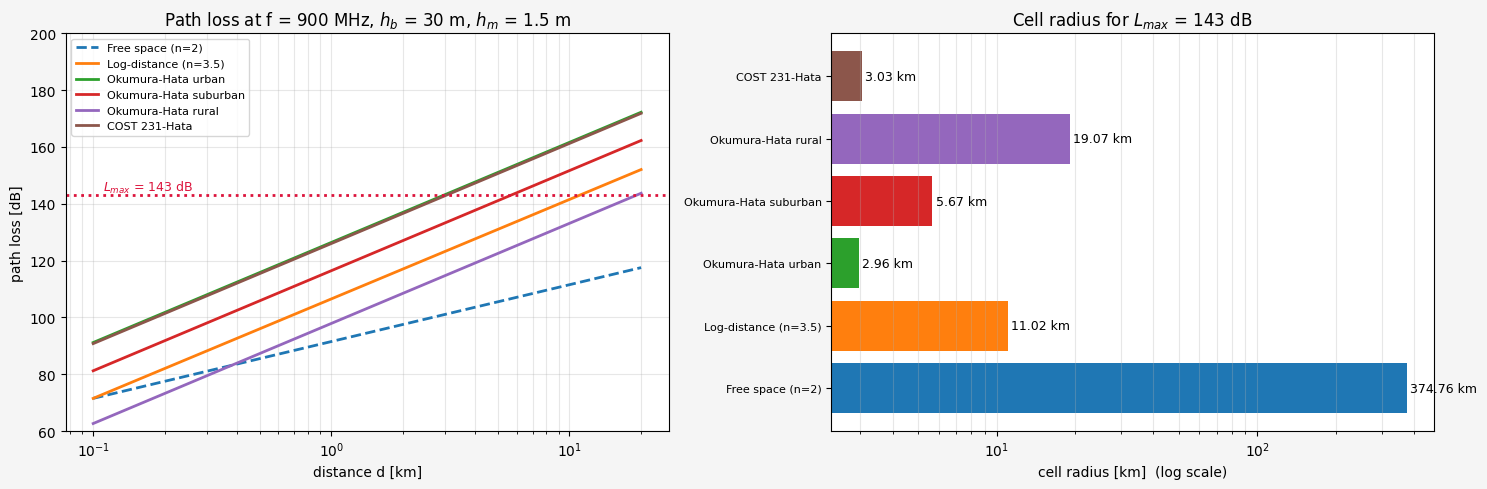

To cover 1000 km2 with hexagonal cells (area = 2.598 R^2):
   Free space (n=2)           R = 374.76 km  ->       0.0 base stations
   Log-distance (n=3.5)       R =  11.02 km  ->       3.2 base stations
   Okumura-Hata urban         R =   2.96 km  ->      44.0 base stations
   Okumura-Hata suburban      R =   5.67 km  ->      12.0 base stations
   Okumura-Hata rural         R =  19.07 km  ->       1.1 base stations
   COST 231-Hata              R =   3.03 km  ->      41.8 base stations


In [5]:
# ---------------------------------------------------------------
#  ALL MODELS IN ONE PICTURE
# ---------------------------------------------------------------
def plot_models(f_MHz=900, h_b=30, h_m=1.5, city='medium', n_log=3.5,
                L_max=143.0, d_max_km=20.0):
    d = np.logspace(np.log10(0.1), np.log10(d_max_km), 400)

    models = {
        'Free space (n=2)':        freespace_AB(f_MHz),
        f'Log-distance (n={n_log:.1f})': logdistance_AB(f_MHz, n_log),
        'Okumura-Hata urban':      hata_AB(f_MHz, h_b, h_m, 'urban', city),
        'Okumura-Hata suburban':   hata_AB(f_MHz, h_b, h_m, 'suburban', city),
        'Okumura-Hata rural':      hata_AB(f_MHz, h_b, h_m, 'rural', city),
        'COST 231-Hata':           cost231_AB(f_MHz, h_b, h_m, city),
    }
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    for i, (name, ab) in enumerate(models.items()):
        ax[0].semilogx(d, L_of_d(ab, d), lw=2, label=name,
                       ls='--' if 'Free' in name else '-')
    ax[0].axhline(L_max, color='crimson', lw=2, ls=':')
    ax[0].text(0.11, L_max+1.5, f"$L_{{max}}$ = {L_max:.0f} dB",
               color='crimson', fontsize=9)
    ax[0].set_xlabel("distance d [km]"); ax[0].set_ylabel("path loss [dB]")
    ax[0].set_title(f"Path loss at f = {f_MHz:.0f} MHz, "
                    f"$h_b$ = {h_b:.0f} m, $h_m$ = {h_m:.1f} m")
    ax[0].legend(fontsize=8); ax[0].grid(alpha=.3, which='both')
    ax[0].set_ylim(60, 200)

    # --- resulting cell radii ------------------------------------------
    names  = list(models)
    radii  = [cell_radius(models[k], L_max) for k in names]
    colors = ['C0','C1','C2','C3','C4','C5']
    ax[1].barh(range(len(names)), radii, color=colors)
    for i, r in enumerate(radii):
        ax[1].text(r*1.03, i, f"{r:.2f} km", va='center', fontsize=9)
    ax[1].set_yticks(range(len(names))); ax[1].set_yticklabels(names, fontsize=8)
    ax[1].set_xscale('log'); ax[1].set_xlabel("cell radius [km]  (log scale)")
    ax[1].set_title(f"Cell radius for $L_{{max}}$ = {L_max:.0f} dB")
    ax[1].grid(alpha=.3, axis='x', which='both')
    fig.tight_layout(); plt.show()

    # --- number of base stations for a given area ----------------------
    area_km2 = 1000.0
    print(f"To cover {area_km2:.0f} km2 with hexagonal cells (area = 2.598 R^2):")
    for k, r in zip(names, radii):
        n_bs = area_km2/(2.598*r**2)
        print(f"   {k:<26s} R = {r:6.2f} km  ->  {n_bs:8.1f} base stations")

plot_models()

In [6]:
# ---------------------------------------------------------------
#  INTERACTIVE
# ---------------------------------------------------------------
style  = {'description_width': '210px'}
layout = widgets.Layout(width='560px')

sl_f   = widgets.FloatSlider(value=900, min=150, max=2000, step=10,
            description='frequency f [MHz]:', style=style, layout=layout)
sl_hb  = widgets.FloatSlider(value=30, min=10, max=200, step=1,
            description='BS height h_b [m]:', style=style, layout=layout)
sl_hm  = widgets.FloatSlider(value=1.5, min=1, max=10, step=0.1,
            description='MS height h_m [m]:', style=style, layout=layout)
dd_ct  = widgets.Dropdown(options=['medium', 'large'], value='medium',
            description='city size:', style=style, layout=layout)
sl_n   = widgets.FloatSlider(value=3.5, min=2.0, max=5.0, step=0.1,
            description='log-distance exponent n:', style=style, layout=layout)
sl_L   = widgets.FloatSlider(value=143, min=100, max=180, step=1,
            description='max. path loss L_max [dB]:', style=style, layout=layout)

def update(f, hb, hm, city, n, L):
    plot_models(f, hb, hm, city, n, L)
    print()
    for nm in ('Okumura-Hata', 'COST 231-Hata'):
        msgs = check_validity(nm, f, 20, hb, hm)
        print(f"{nm:<15s}: " + ("within its validity range"
              if not msgs else "OUTSIDE validity -> " + "; ".join(msgs)))

ui  = widgets.VBox([sl_f, sl_hb, sl_hm, dd_ct, sl_n, sl_L])
out = widgets.interactive_output(update, {'f': sl_f, 'hb': sl_hb, 'hm': sl_hm,
                                          'city': dd_ct, 'n': sl_n, 'L': sl_L})
display(ui, out)

Output()

## 📝 Try this

1. **Feed in your own link budget.** Set $L_{max}$ to the 143 dB you calculated for
   GSM1800 in slide set 1 and read off the cell radius in each environment. Then look at
   the base-station count printed below the plot — that difference is the entire business
   case for a network.
2. **Raise the mast.** Push $h_b$ from 30 m to 60 m. Two things change: the constant term
   drops **and** the slope $B$ gets shallower. Height helps twice over, which is why
   operators fight for rooftops.
3. **Cross the model boundary.** Slide the frequency past 1500 MHz and watch the validity
   line at the bottom. Okumura–Hata goes out of range and COST 231 comes into range —
   that is precisely why COST 231 was created.
4. **Urban vs. rural.** At the same $L_{max}$, compare the two radii. Then remember
   Exercise 6 from slide set 1: it is the same statement, expressed with an exponent
   instead of a fitted formula.
5. **Compare with reality.** Set $n$ so the log-distance line lies on top of the
   Okumura–Hata urban line. What exponent did you need? It should land near 3.5 — the
   value the slide quotes for urban scenarios.

## 📌 Summary

| Model | Frequency range | Typical use |
|---|---|---|
| Free space | any | optimistic reference only |
| Log-distance | any | quick estimates, indoor with measured $n$ |
| Okumura–Hata | 150 MHz – 1.5 GHz | macrocells, GSM-R planning |
| COST 231–Hata | 1.5 – 2 GHz | macrocells, GSM1800 / UMTS |
| COST-Walfish-Ikegami | urban | microcells, includes over-roof diffraction |

All of them are **empirical**: fitted to measurement campaigns, valid only inside the
ranges they were fitted for. Using one outside its range is the most common mistake in
coverage planning — hence the validity check under the plot.